In [64]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [65]:
df=pd.read_csv("smartcart_customers.csv")

In [66]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


In [67]:
df.isna().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
dtype: int64

# 1.Data Preprocessing

# Handling Missing Values

In [68]:
df["Income"]=df["Income"].fillna(df["Income"].median())


In [69]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


In [70]:
#Customer age
df["Age"]=2026-df["Year_Birth"]

In [71]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,88,88,3,8,10,4,7,0,1,69
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,1,6,2,1,1,2,5,0,0,72
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,21,42,1,8,2,10,4,0,0,61
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,3,5,2,2,0,4,6,0,0,42
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,27,15,5,5,3,6,5,0,0,45


In [72]:
# Customer joining date
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"],dayfirst=True)

reference_date=df["Dt_Customer"].max()
df["Customer_tenure_date"]= (reference_date-df["Dt_Customer"]).dt.days

In [73]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'Age', 'Customer_tenure_date'],
      dtype='object')

In [86]:
df["Total_spending"]=df["MntWines"] + df["MntFruits"] + df["MntMeatProducts"] + df["MntFishProducts"] + df["MntSweetProducts"] + df["MntGoldProds"]

In [87]:
df["Total_children"]=df["Kidhome"] + df["Teenhome"]

In [88]:
df["Education"].value_counts()

Education
Graduate         1127
PostGraduate      856
UnderGraduate     257
Name: count, dtype: int64

In [89]:
# Education
df["Education"]=df["Education"].replace(
    {
        "2n Cycle":"UnderGraduate",
        "Basic":"UnderGraduate",
        "Graduation":"Graduate",
        "PhD":"PostGraduate",
        "Master":"PostGraduate"
    }
)

In [90]:
# Marrital Status
df["Living_with"]=df["Marital_Status"].replace(
    {
        "Married":"Partner",
        "Together":"Partner",
        "Single":"Alone",
        "Divorced":"Alone",
        "Widow":"Alone",
        "Absurd":"Alone",
        "YOLO":"Alone"
    }
)

In [91]:
df["Marital_Status"].value_counts()

Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

In [92]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_tenure_date,Total_children,Living_with,Total_spending
0,5524,1957,Graduate,Single,58138.0,0,0,2012-09-04,58,635,...,10,4,7,0,1,69,663,0,Alone,1617
1,2174,1954,Graduate,Single,46344.0,1,1,2014-03-08,38,11,...,1,2,5,0,0,72,113,2,Alone,27
2,4141,1965,Graduate,Together,71613.0,0,0,2013-08-21,26,426,...,2,10,4,0,0,61,312,0,Partner,776
3,6182,1984,Graduate,Together,26646.0,1,0,2014-02-10,26,11,...,0,4,6,0,0,42,139,1,Partner,53
4,5324,1981,PostGraduate,Married,58293.0,1,0,2014-01-19,94,173,...,3,6,5,0,0,45,161,1,Partner,422


# Drop Unncessary Columns

In [93]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'Age', 'Customer_tenure_date', 'Total_children',
       'Living_with', 'Total_spending'],
      dtype='object')

In [94]:
cols=["ID","Year_Birth","Marital_Status","Kidhome","Teenhome","Dt_Customer"]
spending_cols=["MntWines","MntFruits","MntMeatProducts","MntFishProducts","MntSweetProducts","MntGoldProds"]

cols_to_drop= cols + spending_cols

df_cleaned=df.drop(columns=cols_to_drop,axis=1)

In [95]:
df_cleaned.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_tenure_date,Total_children,Living_with,Total_spending
0,Graduate,58138.0,58,3,8,10,4,7,0,1,69,663,0,Alone,1617
1,Graduate,46344.0,38,2,1,1,2,5,0,0,72,113,2,Alone,27
2,Graduate,71613.0,26,1,8,2,10,4,0,0,61,312,0,Partner,776
3,Graduate,26646.0,26,2,2,0,4,6,0,0,42,139,1,Partner,53
4,PostGraduate,58293.0,94,5,5,3,6,5,0,0,45,161,1,Partner,422


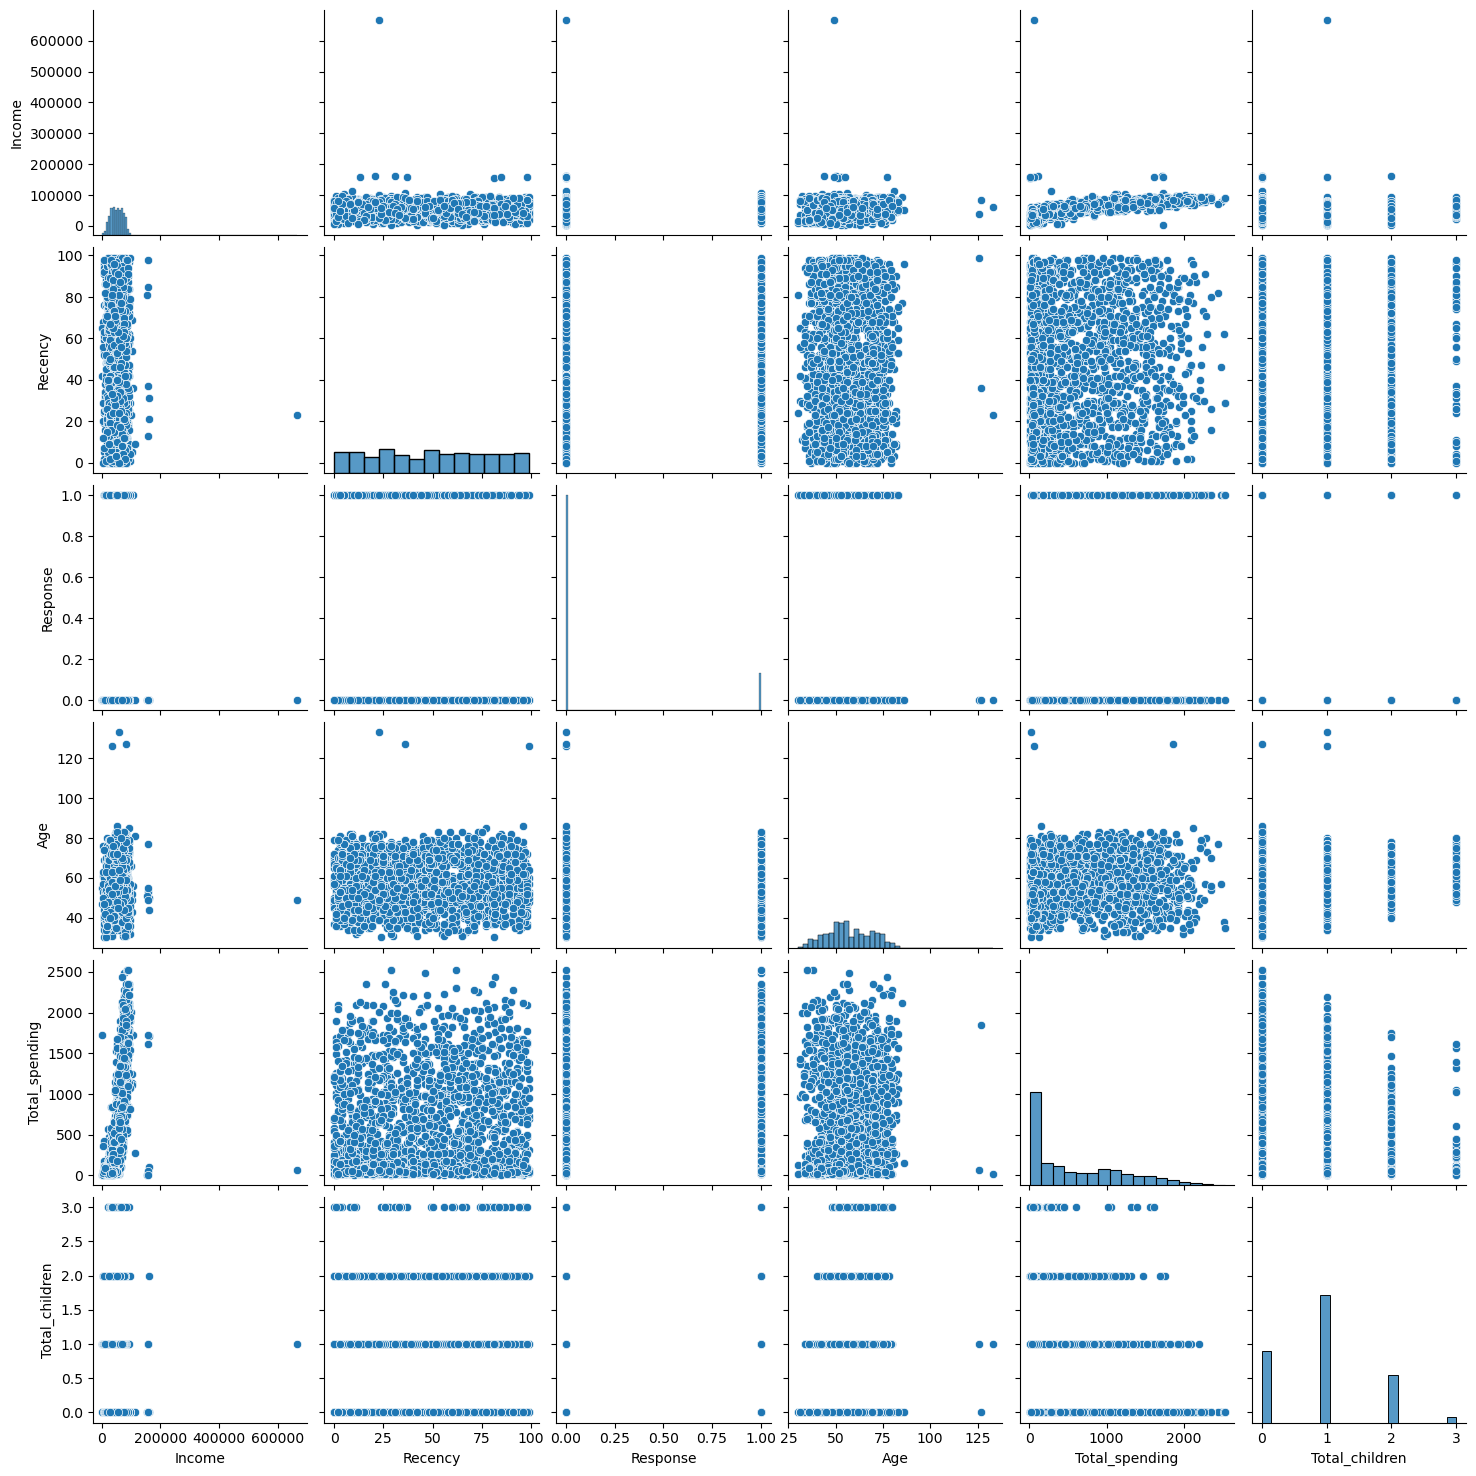

In [96]:
# Outliers detection
col=["Income","Recency","Response","Age","Total_spending","Total_children"]

# relative plot of some features -pair plot
sns.pairplot(df_cleaned[col])

In [97]:
# outliers remove
df_cleaned=df_cleaned[(df_cleaned["Age"]<90)]
df_cleaned=df_cleaned[(df_cleaned["Income"]<600_000)]
print("data without Outliers:",len(df_cleaned))

data without Outliers: 2236


# Correlation HeatMap

In [98]:
corr_matrix=df_cleaned.corr(numeric_only=True)

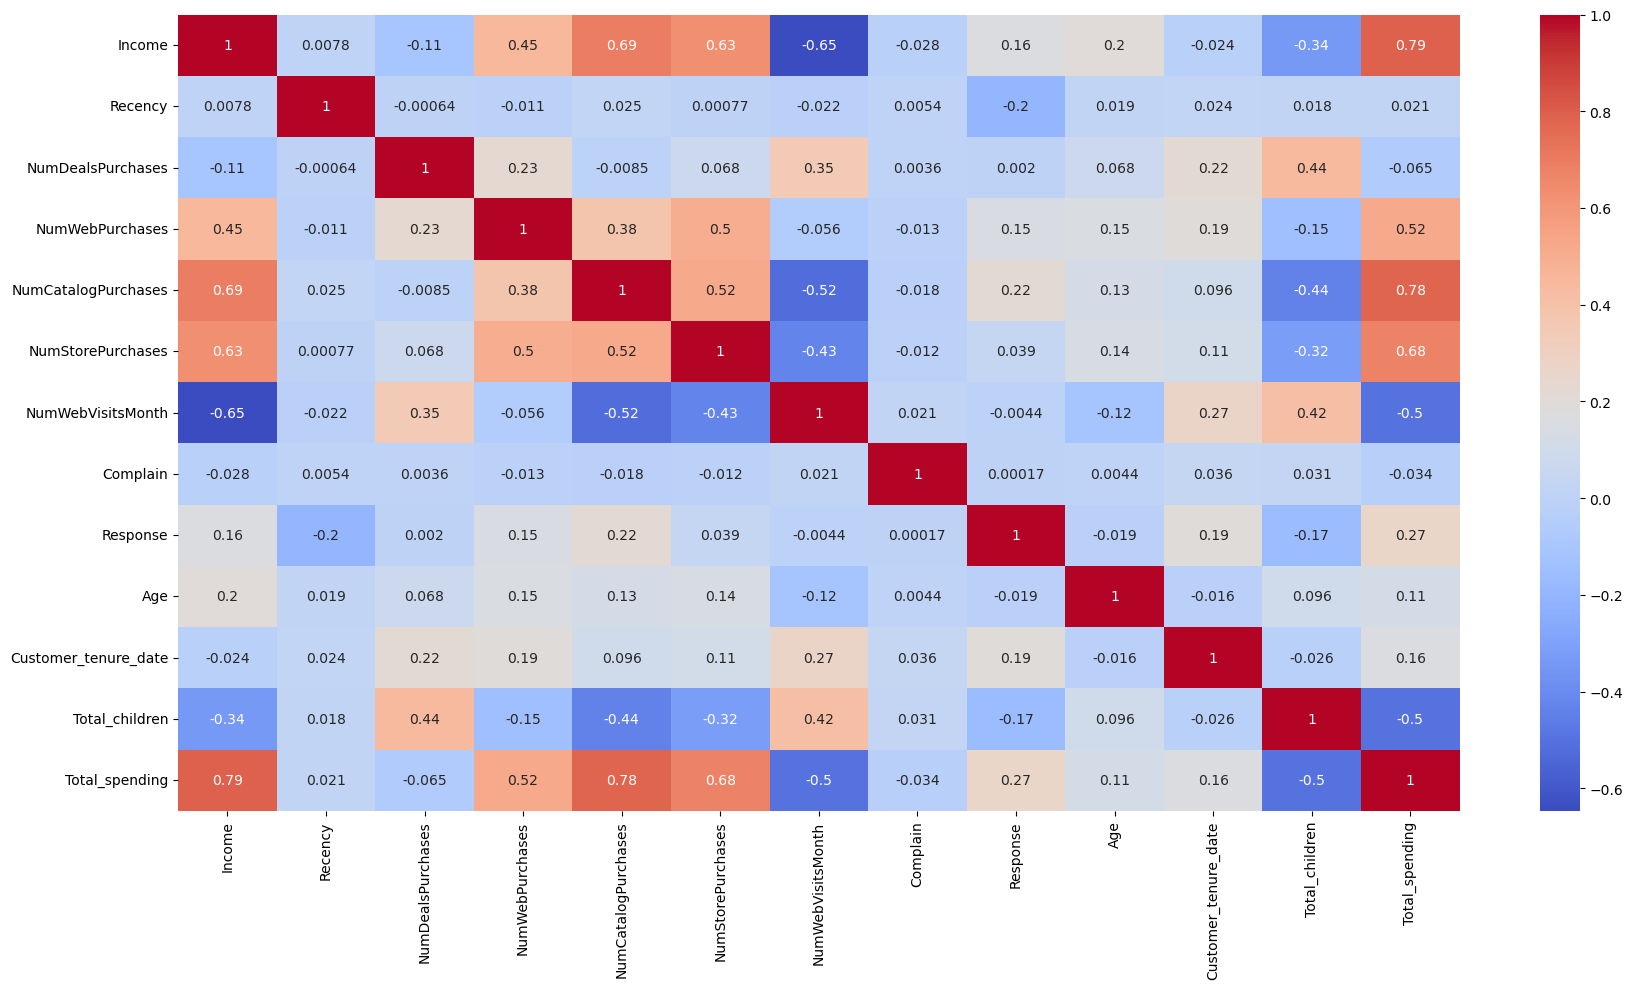

In [99]:
plt.figure(figsize=(18,10))
sns.heatmap(corr_matrix,annot=True,cmap="coolwarm")
plt.tight_layout()

# feature Encoding


In [100]:
from sklearn.preprocessing import OneHotEncoder

cat_cols=["Education","Living_with"]

ohe=OneHotEncoder()
encoded_cols=ohe.fit_transform(df_cleaned[cat_cols])

enc_df=pd.DataFrame(encoded_cols.toarray(),columns=ohe.get_feature_names_out(cat_cols),index=df_cleaned.index)

In [101]:
df_encoded=pd.concat([df_cleaned.drop(columns=cat_cols),enc_df],axis=1)

In [102]:
df_encoded.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_tenure_date,Total_children,Total_spending,Education_Graduate,Education_PostGraduate,Education_UnderGraduate,Living_with_Alone,Living_with_Partner
0,58138.0,58,3,8,10,4,7,0,1,69,663,0,1617,1.0,0.0,0.0,1.0,0.0
1,46344.0,38,2,1,1,2,5,0,0,72,113,2,27,1.0,0.0,0.0,1.0,0.0
2,71613.0,26,1,8,2,10,4,0,0,61,312,0,776,1.0,0.0,0.0,0.0,1.0
3,26646.0,26,2,2,0,4,6,0,0,42,139,1,53,1.0,0.0,0.0,0.0,1.0
4,58293.0,94,5,5,3,6,5,0,0,45,161,1,422,0.0,1.0,0.0,0.0,1.0


# Scaled Data

In [103]:
from sklearn.preprocessing import StandardScaler
X=df_encoded
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)

# Visualize data

In [104]:
from sklearn.decomposition import PCA

pca=PCA(n_components=3)
pca_data=pca.fit_transform(X_scaled)

In [105]:
pca.explained_variance_ratio_

array([0.23163158, 0.11385454, 0.10405815])

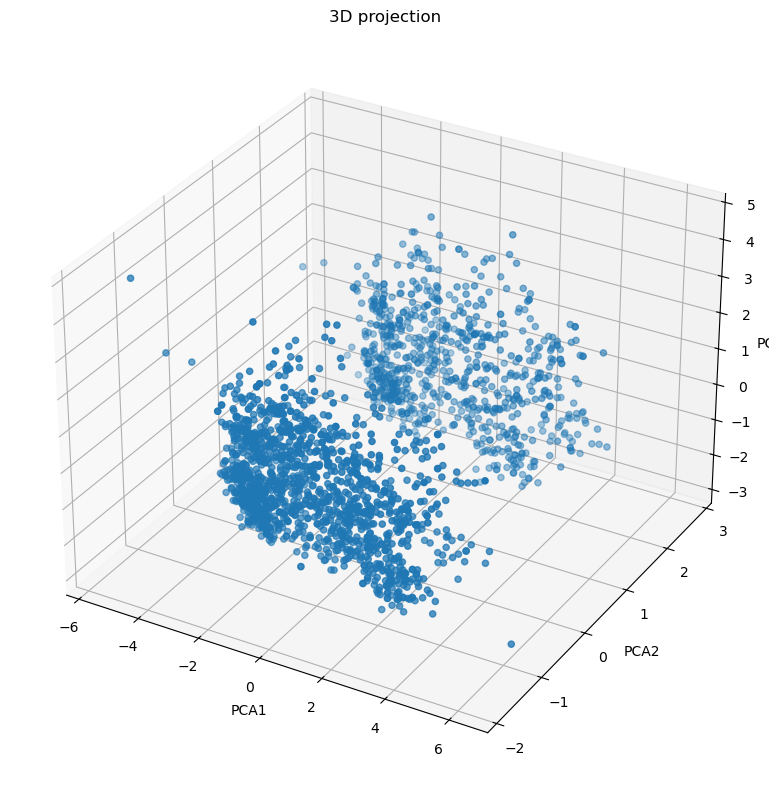

In [107]:
fig=plt.figure(figsize=(15,8))
ax=fig.add_subplot(111,projection="3d")
ax.scatter(pca_data[:,0],pca_data[:,1],pca_data[:,2])
ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")
ax.set_title("3D projection")
plt.tight_layout()

# Analye K value

In [108]:
from sklearn.cluster import KMeans
from kneed import KneeLocator

wcss=[]
for k in range(1,11):
    kmeans=KMeans(n_clusters=k,random_state=42)
    kmeans.fit_predict(pca_data)
    labels=kmeans.inertia_
    wcss.append(labels)

C:\Users\ANIKET\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
C:\Users\ANIKET\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
C:\Users\ANIKET\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
C:\Users\ANIKET\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Wi

In [109]:
knee=KneeLocator(range(1,11),wcss,curve="convex",direction="decreasing")
optimal_k=knee.elbow
print("best k:",optimal_k)

best k: 4


In [110]:
kmeans=KMeans(n_clusters=4)
labels=kmeans.fit_predict(pca_data)


C:\Users\ANIKET\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(


<Axes: >

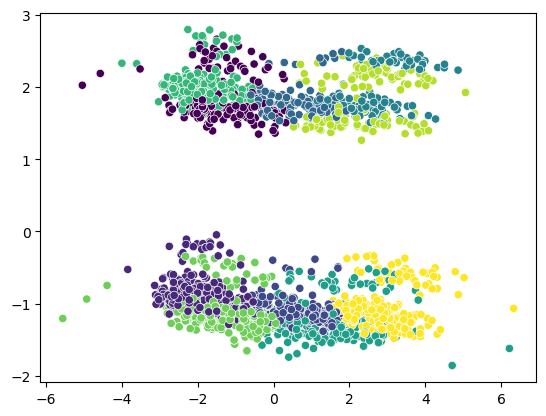

In [115]:
sns.scatterplot(x=pca_data[:,0],y=pca_data[:,1],c=labels)

In [116]:
# silhouette score

from sklearn.metrics import silhouette_score
ss=[]
for k in range(2,11):
    kmeans=KMeans(n_clusters=k)
    labels=kmeans.fit_predict(pca_data)
    score=silhouette_score(pca_data,labels)
    ss.append(score)

C:\Users\ANIKET\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
C:\Users\ANIKET\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
C:\Users\ANIKET\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
C:\Users\ANIKET\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Wi

<Axes: >

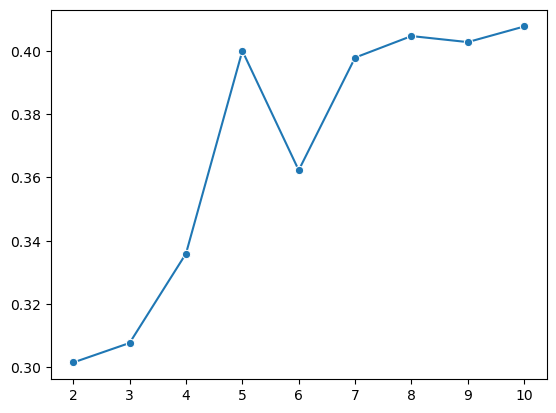

In [117]:
sns.lineplot(x=range(2,11),y=ss,marker="o")

Text(0, 0.5, 'SS')

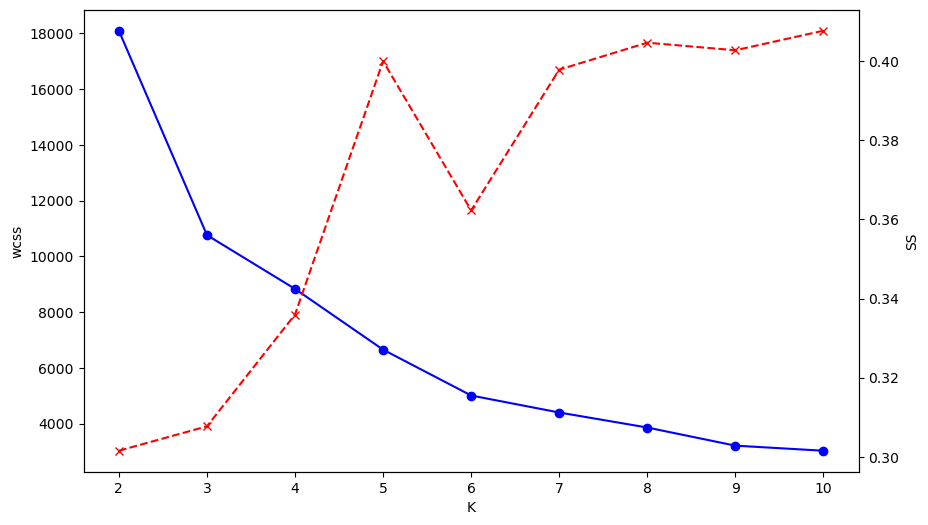

In [118]:
# comnined plot

K_range=range(2,11)
fig,ax1 =plt.subplots(figsize=(10,6))
ax1.plot(K_range,wcss[:len(K_range)],marker="o",c="blue")
ax1.set_xlabel("K")
ax1.set_ylabel("wcss")

ax2=ax1.twinx()
ax2.plot(K_range,ss[:len(K_range)],marker="x" , c="red",linestyle="--")
ax2.set_ylabel("SS")

# Clustering

C:\Users\ANIKET\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(


Text(0.5, 0.92, 'KMeans Clustering')

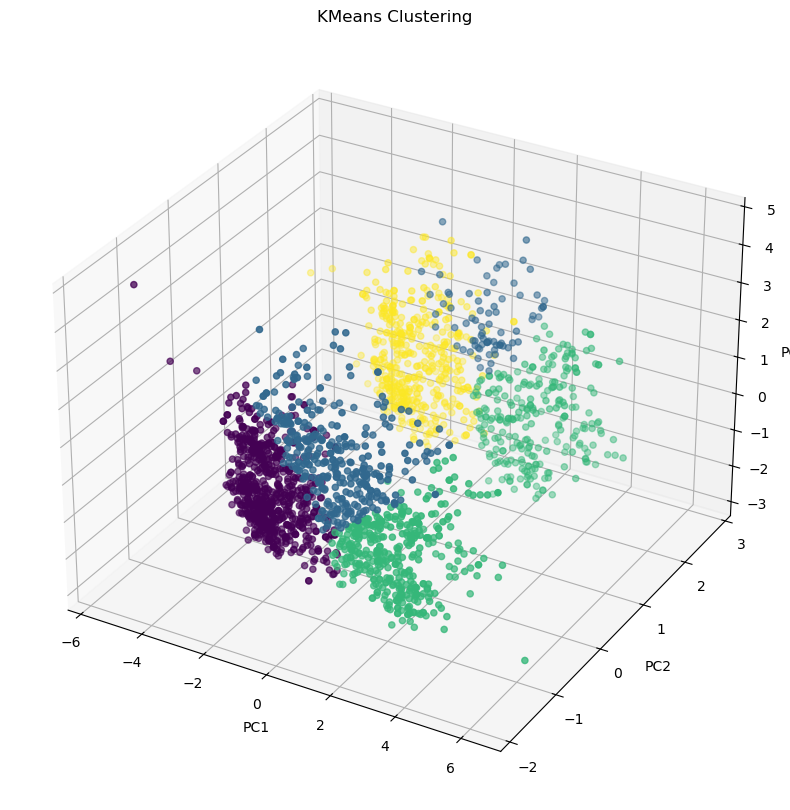

In [119]:
kmeans=KMeans(n_clusters=4,random_state=42)
labels_kmeans=kmeans.fit_predict(pca_data)

fig=plt.figure(figsize=(18,10))
ax=fig.add_subplot(111,projection="3d")

ax.scatter(pca_data[:,0],pca_data[:,1],pca_data[:,2],c=labels_kmeans)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC2")
ax.set_title("KMeans Clustering")

Text(0.5, 0.92, 'KMeans Clustering')

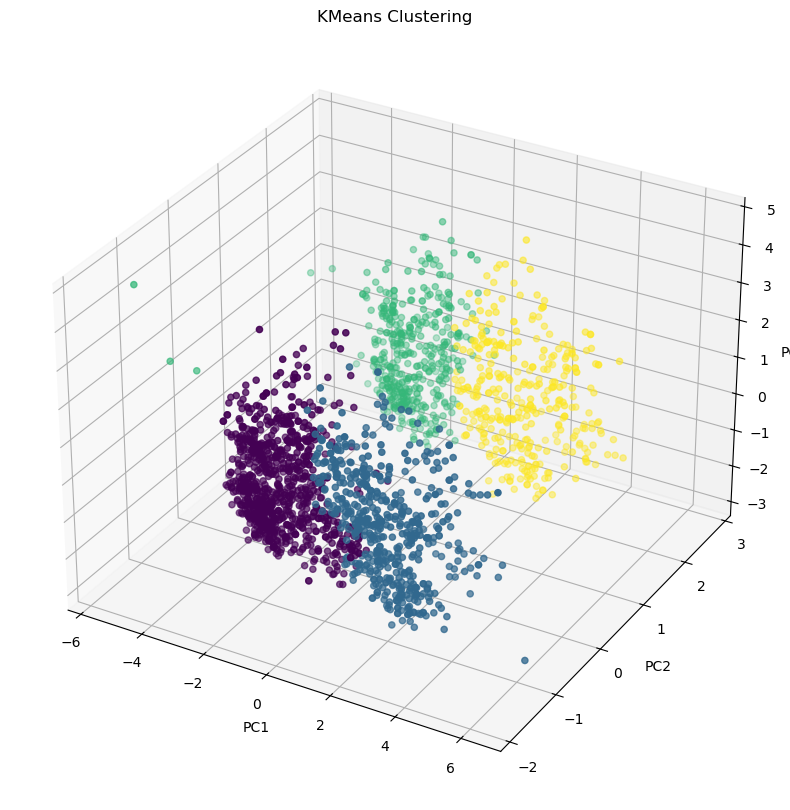

In [120]:
from sklearn.cluster import AgglomerativeClustering
agg= AgglomerativeClustering(n_clusters=4,linkage="ward")
labels_agg=agg.fit_predict(pca_data)

fig=plt.figure(figsize=(18,10))
ax=fig.add_subplot(111,projection="3d")

ax.scatter(pca_data[:,0],pca_data[:,1],pca_data[:,2],c=labels_agg)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC2")
ax.set_title("KMeans Clustering")

<Axes: xlabel='clusters', ylabel='count'>

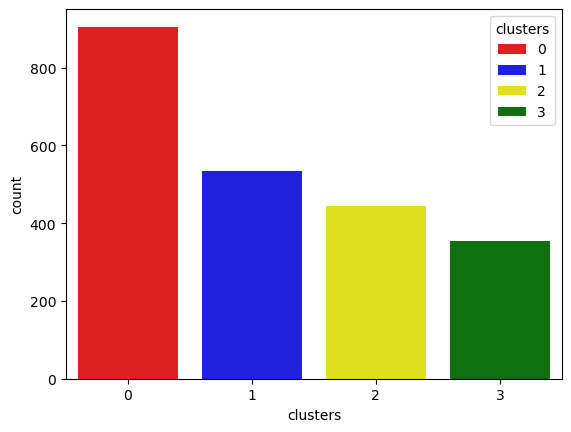

In [128]:
# Characterization Cluster
pal=["red","blue","yellow","green"]
X["clusters"]=labels_agg

sns.countplot(x=X["clusters"],palette=pal,hue=X["clusters"])

<Axes: xlabel='Total_spending', ylabel='Income'>

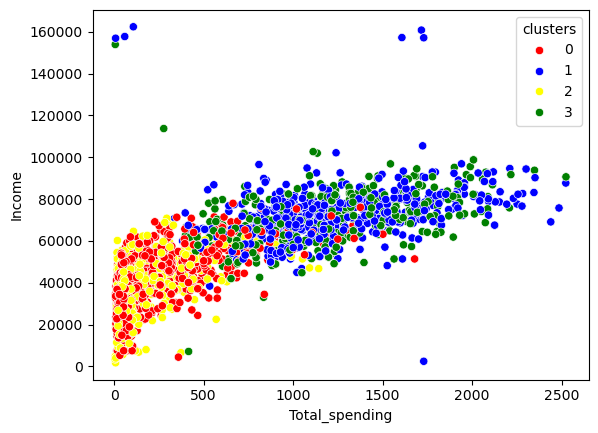

In [129]:
sns.scatterplot(x=X["Total_spending"],y=X["Income"],hue=X["clusters"],palette=pal)

In [130]:
cluster_Summary = X.groupby("clusters").mean()
print(cluster_Summary)

                Income    Recency  NumDealsPurchases  NumWebPurchases  \
clusters                                                                
0         39680.580110  48.914917           2.594475         3.153591   
1         72808.445693  49.202247           1.958801         5.687266   
2         36960.143018  48.319820           2.594595         2.713964   
3         70722.681303  50.504249           1.855524         5.790368   

          NumCatalogPurchases  NumStorePurchases  NumWebVisitsMonth  Complain  \
clusters                                                                        
0                    0.969061           4.143646           6.307182  0.011050   
1                    5.498127           8.659176           3.580524  0.005618   
2                    0.837838           3.623874           6.659910  0.011261   
3                    5.014164           8.430595           3.728045  0.005666   

          Response        Age  Customer_tenure_date  Total_children  \
clu